# 暂退法（Dropout）

在 [4.5节](./04.05_weight_decay.ipynb) 中，我们介绍了通过惩罚权重的$L_2$范数来正则化统计模型的经典方法。在概率角度看，我们可以通过以下论证来证明这一技术的合理性：我们已经假设了一个先验，即权重的值取自均值为0的高斯分布。更直观的是，我们希望模型深度挖掘特征，即将其权重分散到许多特征中，而不是过于依赖少数潜在的虚假关联。


---
## 环境配置


In [1]:
%pip install pypto==0.2.0 torch torch_npu numpy

In [2]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import pypto.pypto_impl as impl
import torch
import torch_npu
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
impl.DeviceInit()

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# 从共享算子库导入 NPU 算子（定义见 ./src/pypto_ops.py）
from src.pypto_ops import (PyPTOMatmul, PyPTOBiasAdd, PyPTOReLUOp,
                           PyPTOLinear, PyPTOReLU, PyPTODropout, loss_fn)


---


## 重新审视过拟合

当面对更多的特征而样本不足时，线性模型往往会过拟合。相反，当给出更多样本而不是特征，通常线性模型不会过拟合。不幸的是，线性模型泛化的可靠性是有代价的。简单地说，线性模型没有考虑到特征之间的交互作用。对于每个特征，线性模型必须指定正的或负的权重，而忽略其他特征。

泛化性和灵活性之间的这种基本权衡被描述为*偏差-方差权衡*（bias-variance tradeoff）。线性模型有很高的偏差：它们只能表示一小类函数。然而，这些模型的方差很低：它们在不同的随机数据样本上可以得出相似的结果。

深度神经网络位于偏差-方差谱的另一端。与线性模型不同，神经网络并不局限于单独查看每个特征，而是学习特征之间的交互。例如，神经网络可能推断“尼日利亚”和“西联汇款”一起出现在电子邮件中表示垃圾邮件，但单独出现则不表示垃圾邮件。

即使我们有比特征多得多的样本，深度神经网络也有可能过拟合。2017年，一组研究人员通过在随机标记的图像上训练深度网络。这展示了神经网络的极大灵活性，因为人类很难将输入和随机标记的输出联系起来，但通过随机梯度下降优化的神经网络可以完美地标记训练集中的每一幅图像。想一想这意味着什么？假设标签是随机均匀分配的，并且有10个类别，那么分类器在测试数据上很难取得高于10%的精度，那么这里的泛化差距就高达90%，如此严重的过拟合。

深度网络的泛化性质令人费解，而这种泛化性质的数学基础仍然是悬而未决的研究问题。我们鼓励喜好研究理论的读者更深入地研究这个主题。本节，我们将着重对实际工具的探究，这些工具倾向于改进深层网络的泛化性。
## 扰动的稳健性

在探究泛化性之前，我们先来定义一下什么是一个“好”的预测模型？我们期待“好”的预测模型能在未知的数据上有很好的表现：经典泛化理论认为，为了缩小训练和测试性能之间的差距，应该以简单的模型为目标。简单性以较小维度的形式展现，我们在 [4.4节](./04.04_underfit_overfit.ipynb) 讨论线性模型的单项式函数时探讨了这一点。此外，正如我们在 [4.5节](./04.05_weight_decay.ipynb) 中讨论权重衰减（$L_2$正则化）时看到的那样，参数的范数也代表了一种有用的简单性度量。

简单性的另一个角度是平滑性，即函数不应该对其输入的微小变化敏感。例如，当我们对图像进行分类时，我们预计向像素添加一些随机噪声应该是基本无影响的。1995年，克里斯托弗·毕晓普证明了具有输入噪声的训练等价于Tikhonov正则化 (Bishop, 1995)。这项工作用数学证实了“要求函数光滑”和“要求函数对输入的随机噪声具有适应性”之间的联系。

然后在2014年，斯里瓦斯塔瓦等人 (Srivastava et al., 2014)就如何将毕晓普的想法应用于网络的内部层提出了一个想法：在训练过程中，他们建议在计算后续层之前向网络的每一层注入噪声。因为当训练一个有多层的深层网络时，注入噪声只会在输入-输出映射上增强平滑性。

这个想法被称为*暂退法*（dropout）。暂退法在前向传播过程中，计算每一内部层的同时注入噪声，这已经成为训练神经网络的常用技术。这种方法之所以被称为*暂退法*，因为我们从表面上看是在训练过程中丢弃（drop out）一些神经元。在整个训练过程的每一次迭代中，标准暂退法包括在计算下一层之前将当前层中的一些节点置零。

需要说明的是，暂退法的原始论文提到了一个关于有性繁殖的类比：神经网络过拟合与每一层都依赖于前一层激活值相关，称这种情况为“共适应性”。作者认为，暂退法会破坏共适应性，就像有性生殖会破坏共适应的基因一样。

那么关键的挑战就是如何注入这种噪声。一种想法是以一种*无偏向*（unbiased）的方式注入噪声。这样在固定住其他层时，每一层的期望值等于没有噪音时的值。

在毕晓普的工作中，他将高斯噪声添加到线性模型的输入中。在每次训练迭代中，他将从均值为零的分布$\epsilon \sim \mathcal{N}(0,\sigma^2)$采样噪声添加到输入$\mathbf{x}$，从而产生扰动点$\mathbf{x}' = \mathbf{x} + \epsilon$，预期是$E[\mathbf{x}'] = \mathbf{x}$。

在标准暂退法正则化中，通过按保留（未丢弃）的节点的分数进行规范化来消除每一层的偏差。换言之，每个中间活性值$h$以*暂退概率*$p$由随机变量$h'$替换，如下所示：

$$
\begin{aligned}
h' =
\begin{cases}
    0 & \text{ 概率为 } p \\
    \frac{h}{1-p} & \text{ 其他情况}
\end{cases}
\end{aligned}
$$

根据此模型的设计，其期望值保持不变，即$E[h'] = h$。
## 实践中的暂退法

回想一下 [4.1节](./04.01_mlp.ipynb)中带有1个隐藏层和5个隐藏单元的多层感知机。当我们将暂退法应用到隐藏层，以$p$的概率将隐藏单元置为零时，结果可以看作一个只包含原始神经元子集的网络。比如在 下图中，删除了$h_2$和$h_5$，因此输出的计算不再依赖于$h_2$或$h_5$，并且它们各自的梯度在执行反向传播时也会消失。这样，输出层的计算不能过度依赖于$h_1, \ldots, h_5$的任何一个元素。

![dropout前后的多层感知机](./images/dropout2.svg)

通常，我们在测试时不用暂退法。给定一个训练好的模型和一个新的样本，我们不会丢弃任何节点，因此不需要标准化。然而也有一些例外：一些研究人员在测试时使用暂退法，用于估计神经网络预测的“不确定性”：如果通过许多不同的暂退法遮盖后得到的预测结果都是一致的，那么我们可以说网络发挥更稳定。
## 从零开始实现

要实现单层的暂退法函数，我们从均匀分布$U[0, 1]$中抽取样本，样本数与这层神经网络的维度一致。然后我们保留那些对应样本大于$p$的节点，把剩下的丢弃。暂退法的前向与反向的数学公式如下：

$$
\begin{array}{c|c}
 & \text{Dropout} \\ \hline
\text{前向} & h' = \begin{cases} 0 & \text{概率 } p \\ \dfrac{h}{1-p} & \text{概率 } 1-p \end{cases} \\ \hline
\text{反向} & \dfrac{\partial h'}{\partial h} = \begin{cases} 0 & u \leq p \\ \dfrac{1}{1-p} & u > p \end{cases}
\end{array}
$$

在下面的代码中，**我们实现 `dropout_layer` 函数，该函数以`dropout`的概率丢弃张量输入`X`中的元素**，如上所述重新缩放剩余部分：将剩余部分除以`1.0-dropout`。

下面我们用 pypto 在 NPU 上实现 `dropout_layer`。本节先把 dropout 写为函数，简洁实现再从 `src.pypto_ops` 导入封装好的 `PyPTODropout(nn.Module)`。下面的实现与 `src` 中的 `PyPTODropoutFunction` 逻辑完全一致，仅改名避免命名冲突。


In [3]:
# 工厂函数：每个 p 值编译一份专用 kernel
# （p 不能作为 kernel 形参被 trace，因为它要进入 `uniform > p` / `x/(1-p)` 作张量运算操作数）
# 函数名中的inline只是为了和src/pypto_ops中的函数区分
def make_dropout_kernels_inline(p: float):
    @pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
    def dropout_fwd_kernel(
        x: pypto.Tensor([], pypto.DT_FP32),
        uniform: pypto.Tensor([], pypto.DT_FP32),
        y: pypto.Tensor([], pypto.DT_FP32),
    ):
        pypto.set_vec_tile_shapes(128, 128)
        y.move(pypto.where(uniform > p, x / (1.0 - p), 0.0))

    @pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
    def dropout_bwd_kernel(
        uniform: pypto.Tensor([], pypto.DT_FP32),
        grad_y: pypto.Tensor([], pypto.DT_FP32),
        grad_x: pypto.Tensor([], pypto.DT_FP32),
    ):
        pypto.set_vec_tile_shapes(128, 128)
        grad_x.move(pypto.where(uniform > p, grad_y / (1.0 - p), 0.0))

    return dropout_fwd_kernel, dropout_bwd_kernel


# kernel 缓存：按 p 值缓存编译好的 kernel 对，避免重复编译
_kernel_cache_inline = {}

def _get_kernels_inline(p: float):
    if p not in _kernel_cache_inline:
        _kernel_cache_inline[p] = make_dropout_kernels_inline(p)
    return _kernel_cache_inline[p]


# 用 torch.autograd.Function 封装，连接 pypto kernel 与 PyTorch 自动微分
class PyPTODropoutFunctionInline(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, p):
        assert 0 <= p <= 1
        if p == 0:
            ctx.mode = 0  # 全保留：前向恒等，反向 grad_x = grad_y
            return x
        if p == 1:
            ctx.mode = 1  # 全丢弃：前向置 0，反向 grad_x = 0
            return torch.zeros_like(x)
        ctx.mode = None
        fwd_kernel, bwd_kernel = _get_kernels_inline(p)
        uniform = torch.rand_like(x)
        y = torch.empty_like(x)
        fwd_kernel(x, uniform, y)
        ctx.save_for_backward(uniform)  # 反向由 uniform 重算掩码（单输出 kernel）
        ctx.bwd_kernel = bwd_kernel
        return y

    @staticmethod
    def backward(ctx, grad_y):
        if ctx.mode == 0:
            return grad_y, None
        if ctx.mode == 1:
            return torch.zeros_like(grad_y), None
        (uniform,) = ctx.saved_tensors
        grad_y = grad_y.contiguous()  # autograd 传入的 grad 可能非连续，kernel 要求连续
        grad_x = torch.empty_like(grad_y)
        ctx.bwd_kernel(uniform.contiguous(), grad_y, grad_x)
        return grad_x, None

# 以 dropout 概率丢弃 X 中的元素，剩余部分除以 1-dropout 保持期望不变。
def dropout_layer(X, dropout):
    return PyPTODropoutFunctionInline.apply(X, dropout)

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><strong>随机数在 kernel 外生成</strong>：<code>uniform = torch.rand_like(x)</code> 在 <code>forward</code> 内部生成（对用户透明），kernel 只接收已生成好的 uniform 张量。</li>
      <li style="margin: 0 0 8px 0;"><strong>为何 <code>p</code> 用闭包固化</strong>：<code>p</code> 要进入 <code>uniform > p</code> 与 <code>x / (1-p)</code> 作张量运算操作数，trace 期无法求值 <code>1.0 - p</code>；<code>cross_entropy</code> 的 <code>num_classes: int</code> 先例不适用（它仅用于编译期 shape 算术）。每个 <code>p</code> 值编译一份专用 kernel，由 <code>_kernel_cache_inline</code> 缓存。</li>
      <li style="margin: 0 0 8px 0;"><strong>前向用 <code>pypto.where</code></strong>：<code>y = where(uniform &gt; p, x/(1-p), 0)</code>——<code>uniform &gt; p</code> 处保留并按 <code>1/(1-p)</code> 缩放、其余置 0。这与本模块 relu 反向的 <code>where(y &gt; 0, …)</code> 是同款写法。<strong>实测教训</strong>：改用 <code>pypto.cast(pypto.gt(uniform, p), FP32)</code> 在本 NPU 上会得到全 0 掩码（错误），故采用 <code>where</code>。</li>
      <li style="margin: 0 0 8px 0;"><strong>反向 <code>grad_x = where(uniform &gt; p, grad_y/(1-p), 0)</code></strong>：dropout 是逐元素线性缩放，对输入的梯度就是同一掩码乘同样的 <code>1/(1-p)</code>。掩码不单独输出（<strong>双输出 kernel 实测会 segfault</strong>），而是<strong>保存 <code>uniform</code></strong>、在反向 kernel 内由 <code>uniform &gt; p</code> 重算；<code>grad_y</code> 先 <code>.contiguous()</code>（autograd 传入的梯度可能非连续）。</li>
      <li style="margin: 0 0 8px 0;"><strong>早退分支</strong>：<code>p==0</code>（全保留）/<code>p==1</code>（全丢弃）走 Python <code>if</code>（编译期求值，不进 kernel），用 <code>ctx.mode</code> 记录；<code>backward</code> 据 <code>ctx.mode</code> 直接返回 <code>grad_y</code>（p==0）或 <code>0</code>（p==1），数学正确。</li>
    </ul>
  </div>
</details>

我们可以通过下面几个例子来**测试`dropout_layer`函数**。我们将输入`X`通过暂退法操作，暂退概率分别为0、0.5和1。


In [4]:
X = torch.arange(16, dtype=torch.float32, device=device).reshape(2, 8)
print(X)
print(dropout_layer(X, 0.))    # p=0：全部保留
print(dropout_layer(X, 0.5))   # p=0.5：约一半置零，其余 ×2
print(dropout_layer(X, 1.))    # p=1：全部置零

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]], device='npu:0')
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]], device='npu:0')


tensor([[ 0.,  2.,  4.,  6.,  8.,  0.,  0.,  0.],
        [16.,  0.,  0., 22.,  0., 26., 28.,  0.]], device='npu:0')
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='npu:0')


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))
    </pre>
  </div>
</details>

### 定义模型参数

同样，我们使用 [3.5节](../03_pypto_linear_networks/)中引入的Fashion-MNIST数据集。我们**定义具有两个隐藏层的多层感知机，每个隐藏层包含256个单元**。


In [5]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens1, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens1, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens1, num_hiddens2, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_hiddens2, requires_grad=True))
W3 = nn.Parameter(torch.randn(num_hiddens2, num_outputs, requires_grad=True) * 0.01)
b3 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2, W3, b3]
# 将参数移到 NPU
for p in params:
    p.data = p.data.to(device)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
    </pre>
  </div>
</details>

### 定义模型

我们可以将暂退法应用于每个隐藏层的输出（在激活函数之后），并且可以为每一层分别设置暂退概率：常见的技巧是在靠近输入层的地方设置较低的暂退概率。下面的模型将第一个和第二个隐藏层的暂退概率分别设置为0.2和0.5，并且暂退法只在训练期间有效。


In [6]:
dropout1, dropout2 = 0.2, 0.5
is_training = True  # 模块级开关：训练时 True（启用 dropout），评估时必须置 False

def net(X):
    X = X.reshape(-1, num_inputs)
    H1 = PyPTOReLUOp.apply(PyPTOBiasAdd.apply(PyPTOMatmul.apply(X, W1), b1))
    if is_training:
        # 在第一个全连接层之后添加一个 dropout 层
        H1 = dropout_layer(H1, dropout1)
    H2 = PyPTOReLUOp.apply(PyPTOBiasAdd.apply(PyPTOMatmul.apply(H1, W2), b2))
    if is_training:
        # 在第二个全连接层之后添加一个 dropout 层
        H2 = dropout_layer(H2, dropout2)
    return PyPTOBiasAdd.apply(PyPTOMatmul.apply(H2, W3), b3)

def evaluate_accuracy(net, data_iter):
    global is_training
    is_training = False  # 关闭 dropout
    try:
        acc_sum, n = 0.0, 0
        with torch.no_grad():
            for X, y in data_iter:
                X, y = X.to(device), y.to(device)
                logits = net(X)
                acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
                n += y.shape[0]
    finally:
        is_training = True  # 确保即使评估异常也恢复训练时的 dropout 行为
    return acc_sum / n

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)
    </pre>
  </div>
</details>

### **训练和测试**

这类似于前面描述的多层感知机训练和测试。


正在编译 pypto kernel（首次运行约 7-8 分钟，请耐心等待）...


编译完成，耗时 435 秒。接下来可以正常训练了。


第  1 轮, 损失 1.1475, 训练准确率 0.554, 测试准确率 0.726


第  2 轮, 损失 0.5827, 训练准确率 0.787, 测试准确率 0.793


第  3 轮, 损失 0.4850, 训练准确率 0.823, 测试准确率 0.801


...

第  6 轮, 损失 0.3931, 训练准确率 0.856, 测试准确率 0.837


第  7 轮, 损失 0.3781, 训练准确率 0.860, 测试准确率 0.850


第  8 轮, 损失 0.3658, 训练准确率 0.866, 测试准确率 0.804


第  9 轮, 损失 0.3575, 训练准确率 0.869, 测试准确率 0.848


第 10 轮, 损失 0.3425, 训练准确率 0.873, 测试准确率 0.863


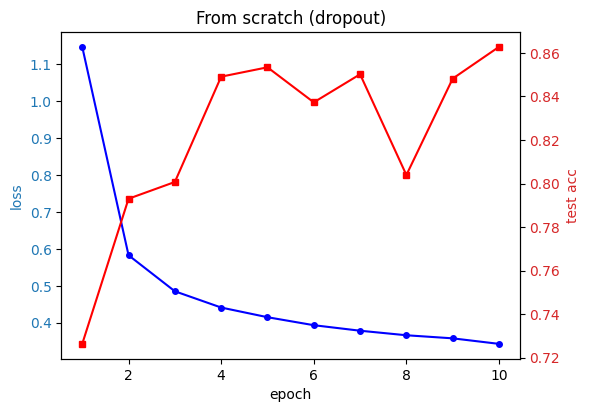

In [7]:
# 加载 Fashion-MNIST 数据集
batch_size = 256
trans = transforms.ToTensor()
mnist_train = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
mnist_test = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
test_iter = DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0)

num_epochs, lr = 10, 0.5
optimizer = torch.optim.SGD(params, lr=lr)

# 预热：触发所有 kernel 的首次编译（含 p=0.2/0.5 的 dropout kernel，首次约 7-8 分钟）
print('正在编译 pypto kernel（首次运行约 7-8 分钟，请耐心等待）...')
import time; t0 = time.time()
Xw, yw = next(iter(train_iter)); Xw, yw = Xw.to(device), yw.to(device)
loss_fn(net(Xw), yw).backward()
for p in params:
    p.grad = None
print(f'编译完成，耗时 {time.time()-t0:.0f} 秒。接下来可以正常训练了。')

train_losses, test_accs = [], []
for epoch in range(num_epochs):
    is_training = True  # 训练阶段启用 dropout
    train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        logits = net(X)
        l = loss_fn(logits, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        train_l_sum += l.item() * y.shape[0]
        train_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]
    train_losses.append(train_l_sum / n)
    test_acc = evaluate_accuracy(net, test_iter)  # 内部关闭/复位 dropout
    test_accs.append(test_acc)
    print(f'第 {epoch + 1:2d} 轮, 损失 {train_l_sum / n:.4f}, '
          f'训练准确率 {train_acc_sum / n:.3f}, 测试准确率 {test_acc:.3f}')

# 绘制训练曲线
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss', color='tab:blue')
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-o', markersize=4)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('test acc', color='tab:red')
ax2.plot(range(1, num_epochs + 1), test_accs, 'r-s', markersize=4)
ax2.tick_params(axis='y', labelcolor='tab:red')
fig.tight_layout(); plt.title('From scratch (dropout)'); plt.show()

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
    </pre>
  </div>
</details>

## **简洁实现**

对于深度学习框架的高级API，我们只需在每个全连接层之后添加一个`Dropout`层，将暂退概率作为唯一的参数传递给它的构造函数。在训练时，`Dropout`层将根据指定的暂退概率随机丢弃上一层的输出（相当于下一层的输入）。在测试时，`Dropout`层仅传递数据。

简洁实现中，dropout 已在 `src/pypto_ops.py` 封装为 `PyPTODropout(nn.Module)`，用法等价于 `nn.Dropout`：`forward` 内根据 `self.training` 决定是否丢弃（`net.eval()` 时直接返回输入），训练/评估切换由 `net.train()` / `net.eval()` 自动管理——无需像从零实现那样手动维护 `is_training` 全局变量。下面用 `nn.Sequential` 把 `PyPTOLinear` / `PyPTOReLU` / `PyPTODropout` 串起来搭建模型。

In [8]:
net = nn.Sequential(
    nn.Flatten(),
    PyPTOLinear(784, 256),
    PyPTOReLU(),
    PyPTODropout(0.2),     # 第一个全连接层之后的 dropout
    PyPTOLinear(256, 256),
    PyPTOReLU(),
    PyPTODropout(0.5),     # 第二个全连接层之后的 dropout
    PyPTOLinear(256, 10)
).to(device)

def init_weights(m):
    if type(m) == PyPTOLinear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)
print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): PyPTOLinear()
  (2): PyPTOReLU()
  (3): PyPTODropout()
  (4): PyPTOLinear()
  (5): PyPTOReLU()
  (6): PyPTODropout()
  (7): PyPTOLinear()
)


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);
    </pre>
  </div>
</details>

接下来，我们**对模型进行训练和测试**。


正在准备 pypto kernel...


准备完成，耗时 9 秒。


第  1 轮, 损失 1.2084, 训练准确率 0.527, 测试准确率 0.689


第  2 轮, 损失 0.5968, 训练准确率 0.779, 测试准确率 0.817


第  3 轮, 损失 0.4926, 训练准确率 0.822, 测试准确率 0.818


...

第  6 轮, 损失 0.4025, 训练准确率 0.855, 测试准确率 0.853


第  7 轮, 损失 0.3809, 训练准确率 0.860, 测试准确率 0.822


第  8 轮, 损失 0.3669, 训练准确率 0.866, 测试准确率 0.841


第  9 轮, 损失 0.3572, 训练准确率 0.869, 测试准确率 0.854


第 10 轮, 损失 0.3429, 训练准确率 0.875, 测试准确率 0.853


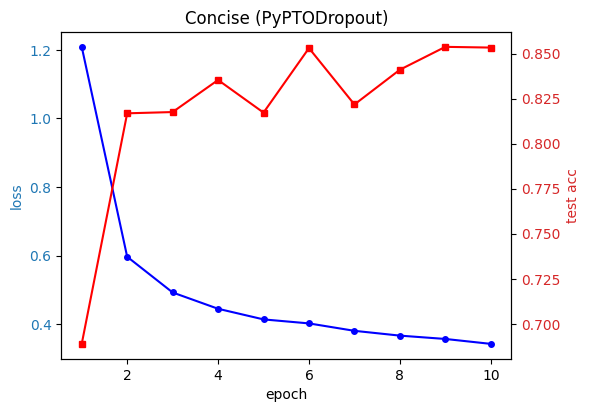

In [9]:
num_epochs, lr = 10, 0.5
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 预热：触发首次编译（kernel 已在从零实现阶段编译过，这里通常很快）
print('正在准备 pypto kernel...')
import time; t0 = time.time()
net.train()
Xw, yw = next(iter(train_iter)); Xw, yw = Xw.to(device), yw.to(device)
loss_fn(net(Xw), yw).backward()
net.zero_grad()
print(f'准备完成，耗时 {time.time()-t0:.0f} 秒。')

train_losses, test_accs = [], []
for epoch in range(num_epochs):
    net.train()  # 训练模式：PyPTODropout 生效
    train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        logits = net(X)
        l = loss_fn(logits, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        train_l_sum += l.item() * y.shape[0]
        train_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]
    train_losses.append(train_l_sum / n)
    # 评估测试集：eval 模式关闭 dropout
    net.eval()
    test_acc_sum, test_n = 0.0, 0
    with torch.no_grad():
        for X, y in test_iter:
            X, y = X.to(device), y.to(device)
            test_acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()
            test_n += y.shape[0]
    test_acc = test_acc_sum / test_n
    test_accs.append(test_acc)
    print(f'第 {epoch + 1:2d} 轮, 损失 {train_l_sum / n:.4f}, '
          f'训练准确率 {train_acc_sum / n:.3f}, 测试准确率 {test_acc:.3f}')

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss', color='tab:blue')
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-o', markersize=4)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('test acc', color='tab:red')
ax2.plot(range(1, num_epochs + 1), test_accs, 'r-s', markersize=4)
ax2.tick_params(axis='y', labelcolor='tab:red')
fig.tight_layout(); plt.title('Concise (PyPTODropout)'); plt.show()

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
    </pre>
  </div>
</details>

---
## 常见错误排查

| 现象 | 可能原因 | 解决方法 |
|------|---------|---------|
| pypto kernel 编译/调用失败，报 `MemCopySync failed` 或 `aicpu exception` | NPU 设备被其他进程占用 | 检查是否有残留 Python 进程占用 NPU：`ps aux | grep python`，杀掉残留进程后重试 |
| 首次运行 pypto kernel 时报错 | 未调用 `DeviceInit()` 初始化 pypto 运行时 | 确保 env 配置 cell 已完整执行（含 `impl.DeviceInit()`），该调用必须在任何 pypto Kernel 之前 |
| 测试准确率明显偏低且每轮抖动 | 评估时仍开着 dropout（从零实现忘记置 `is_training=False`；简洁实现忘记 `net.eval()`） | 从零实现用 `evaluate_accuracy`（内部关闭/复位 `is_training`）；简洁实现评估前 `net.eval()`、训练前 `net.train()` |
| `dropout_layer` 报 `1.0 - p` 无法求值 / kernel trace 失败 | 把 `p` 作为 kernel 形参传入被 trace | `p` 必须用 `make_dropout_kernels_inline(p)` 闭包固化为编译期常量，不能作 kernel 形参 |
| 想用 pypto 内置 RNG 替代 `torch.rand_like` 但行为不符 | `pypto.uniform`/`normal` 是计数器型（需管理 `key`/`counter`）、且设备支持受限、有尾轴 4 的倍数约束 | 本教程用 `torch.rand_like` 更简洁；如需 pypto RNG 请按官方文档管理计数器并确认设备/形状约束 |
| `Reduce op: the tileShape of last axis need 32Byte align!` | tile shape 末维不是 32 字节整数倍 | 隐藏层维度 256/10 已满足；若改动维度需保证末维为 8（FP32）的倍数 |
| Kernel 首次运行等待很久（约 7-8 分钟） | 首次触发编译：p=0.2 与 p=0.5 各编译 fwd/bwd 共 4 份 dropout kernel，加上 matmul/bias_add/relu/softmax/CE | 正常现象，编译结果会缓存（`output/` 目录），后续 epoch 不再等待 |

## 小结

* 暂退法在前向传播过程中，计算每一内部层的同时丢弃一些神经元。
* 暂退法可以避免过拟合，它通常与控制权重向量的维数和大小结合使用的。
* 暂退法将活性值$h$替换为具有期望值$h$的随机变量。
* 暂退法仅在训练期间使用。
## 练习

1. 如果更改第一层和第二层的暂退法概率，会发生什么情况？具体地说，如果交换这两个层，会发生什么情况？设计一个实验来回答这些问题，定量描述该结果，并总结定性的结论。
1. 增加训练轮数，并将使用暂退法和不使用暂退法时获得的结果进行比较。
1. 当应用或不应用暂退法时，每个隐藏层中激活值的方差是多少？绘制一个曲线图，以显示这两个模型的每个隐藏层中激活值的方差是如何随时间变化的。
1. 为什么在测试时通常不使用暂退法？
1. 以本节中的模型为例，比较使用暂退法和权重衰减的效果。如果同时使用暂退法和权重衰减，会发生什么情况？结果是累加的吗？收益是否减少（或者说更糟）？它们互相抵消了吗？
1. 如果我们将暂退法应用到权重矩阵的各个权重，而不是激活值，会发生什么？
1. 发明另一种用于在每一层注入随机噪声的技术，该技术不同于标准的暂退法技术。尝试开发一种在Fashion-MNIST数据集（对于固定架构）上性能优于暂退法的方法。

参考答案详见 [answers/04.06_reference_answer](./answers/04.06_reference_answer.ipynb)。


### 参考答案（PyPTO）


In [ ]:
!cat answers/txt/04.06_reference_answer_pypto.txt

### 参考答案（PyTorch）


In [ ]:
!cat answers/txt/04.06_reference_answer_pytorch.txt